In [1]:
# statsbomb_shots.py
from pathlib import Path
import pandas as pd
import numpy as np
from nodes.utils import collect_all_shots, plot_shots
from nodes.model import SimpleXGModel, AdvancedXGModel
from nodes.plot import create_xg_heatmap, create_xg_heatmap_with_shots, compare_xg_by_technique
import matplotlib.pyplot as plt
import joblib

In [2]:
# import os

# # Go one level higher
# os.chdir("../..")

# # Check current directory
# print(os.getcwd())

### 1. Collect all shots

In [3]:
# OPEN_DATA_DIR = Path("open-data/data")  # adjust if different
# EVENTS_DIR = OPEN_DATA_DIR / "events"

In [4]:
# shots_df = collect_all_shots(EVENTS_DIR)

In [5]:
# shots_df.shape

In [6]:
# competitions

In [7]:
# shots_df.to_csv("shots.csv", index=False)

### 2. Print some of them

In [8]:
# shots_df.iloc[0]

In [9]:
# fig, ax = plot_shots(shots_df, max_shots=10)
# plt.show()

In [10]:
# player_shots = shots_df[shots_df['player_name'] == 'Leandro Greco']
# fig, ax = plot_shots(player_shots)
# plt.show()

### 3. First model

In [11]:
# import os
# os.chdir("../..")
# print(os.getcwd())

In [12]:
shots_df=pd.read_csv("results/shots_after_eda.csv")

In [13]:
# shots_df[shots_df['player_name']=='Lionel Andrés Messi Cuccittini'].iloc[0]

### 3.1 Simple model

In [14]:
# 1. Create and train the model
xg_model_simple = SimpleXGModel()
metrics = xg_model_simple.train(shots_df)

MODEL TRAINING RESULTS
Accuracy: 0.8919
ROC AUC: 0.7967
Log Loss: 0.2877
Actual Goal Rate: 0.1120
Predicted Goal Rate: 0.1127

TOP 10 MOST IMPORTANT FEATURES:
--------------------------------------------------
technique_Lob                 : +1.4457
bodypart_Head                 : -1.4020
technique_Backheel            : -1.3926
technique_Overhead Kick       : -1.2642
technique_Diving Header       : +1.1607
bodypart_Other                : -0.7450
technique_Volley              : -0.6930
bodypart_Right Foot           : +0.6069
angle_to_goal                 : +0.5966
technique_Half Volley         : -0.5518
--------------------------------------------------


In [15]:
xg_model_simple._show_feature_importance()


TOP 10 MOST IMPORTANT FEATURES:
--------------------------------------------------
technique_Lob                 : +1.4457
bodypart_Head                 : -1.4020
technique_Backheel            : -1.3926
technique_Overhead Kick       : -1.2642
technique_Diving Header       : +1.1607
bodypart_Other                : -0.7450
technique_Volley              : -0.6930
bodypart_Right Foot           : +0.6069
angle_to_goal                 : +0.5966
technique_Half Volley         : -0.5518
--------------------------------------------------


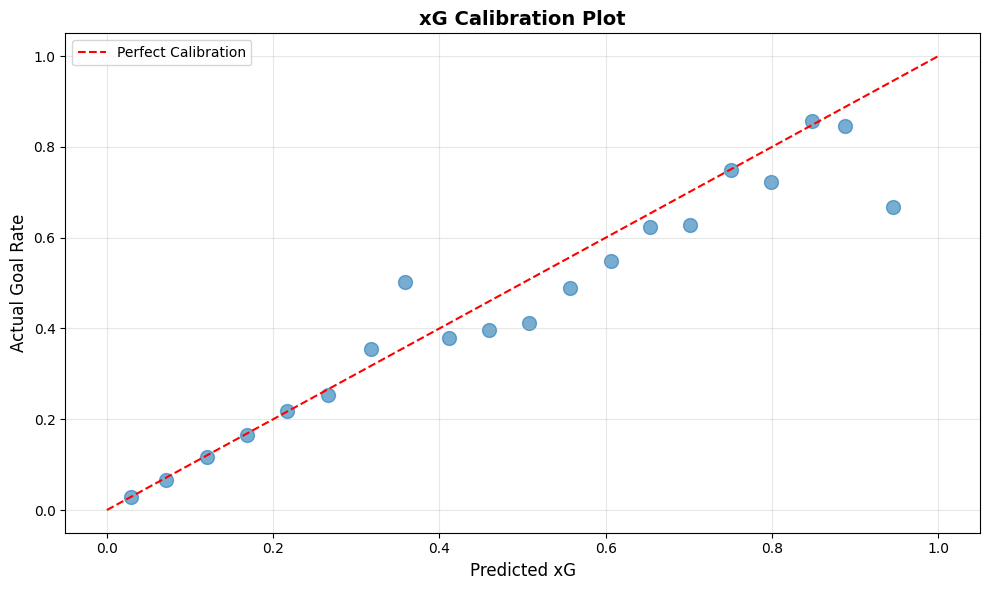

In [16]:
xg_model_simple.plot_xg_calibration(shots_df, bins=20)

In [17]:
# joblib.dump(xg_model, "simple_xg_model.joblib")
# print("Model saved successfully!")

### 3.2 Complex model

In [18]:
model = AdvancedXGModel(n_trials=50, cv_folds=3)
metrics = model.train(shots_df, test_size=0.2)

STARTING HYPERPARAMETER OPTIMIZATION
Total samples: 87386
Train: 55926, Val: 13982, Test: 17478
Running 50 Optuna trials...
------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]


BEST HYPERPARAMETERS FOUND
max_depth           : 4
learning_rate       : 0.10132012816030357
n_estimators        : 202
min_child_weight    : 3
subsample           : 0.8041867198391713
colsample_bytree    : 0.8573868849773337
gamma               : 4.5685785753174555
reg_alpha           : 0.6787297574441722
reg_lambda          : 1.4826662680173994
------------------------------------------------------------

FINAL MODEL EVALUATION (TEST SET)
Accuracy:              0.8985
ROC AUC:               0.7991
Log Loss:              0.2830
Brier Score:           0.0817
Actual Goal Rate:      0.1120
Predicted Goal Rate:   0.1122

TOP 10 MOST IMPORTANT FEATURES:
------------------------------------------------------------
inverse_dist_angle            : 0.3458
angle_to_goal                 : 0.1419
bodypart_Left Foot            : 0.1012
bodypart_Right Foot           : 0.0775
dist_angle_interaction        : 0.0637
dist_to_goal                  : 0.0416
technique_Normal              : 0.0354
angle_sq

In [19]:
shots_with_xg = model.add_xg_to_dataframe(shots_df)

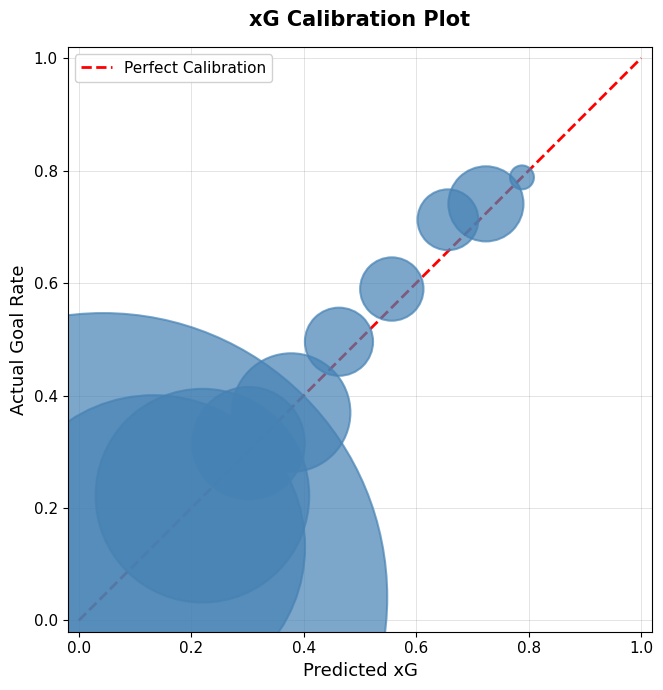

In [22]:
model.plot_xg_calibration_styled(shots_df)

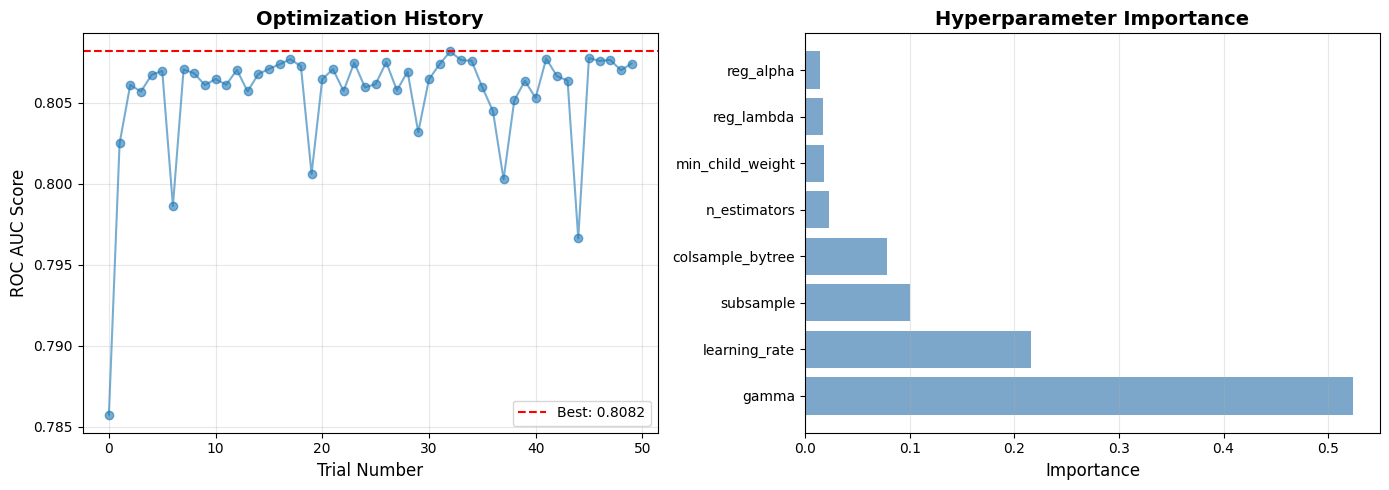

In [10]:
model.plot_optimization_history()

#### Model insights

5% are eliminated with really low xG: shots with a really small probability of turning into a goal

In [41]:
# Add xG predictions
shots_df['xG'] = model.predict_xg(shots_df)

# Remove bottom 5% of xG values (adjust threshold as needed)
xg_threshold = shots_df['xG'].quantile(0.05)  # Bottom 5%
df_filtered = shots_df[shots_df['xG'] > xg_threshold]

In [44]:
(4000/87000)*100

4.597701149425287

### 4. Results

### Analyze the dataframe

In [11]:
shots_df.head()

,match_id,event_id,player_id,player_name,team_id,team_name,minute,second,shot_outcome,shot_body_part,shot_technique,x,y,dist_to_goal,angle_to_goal_rad,angle_to_goal_deg
0,NaN,943d24cf-3f41-41d0-81b9-c7237c374426,32119,Leandro Greco,226,Hellas Verona,9,41,Saved,Left Foot,Half Volley,94.5,54.5,29.334280,0.237022,13.580382
1,NaN,579178b1-c0c2-4e83-ac0f-5004a1c9190a,11502,Antonio Di Gaudio,1683,Carpi,11,3,Off T,Right Foot,Normal,100.6,34.5,20.164573,0.378200,21.669273
2,NaN,ea2c07b1-d3f5-451a-acc8-09a0b8fd2fc7,7696,Ryder Matos Santos,1683,Carpi,14,56,Saved,Left Foot,Half Volley,108.3,47.0,13.634148,0.503568,28.852335
3,NaN,6cb60add-9332-4d3e-b1b7-40155584f2c9,6686,Giampaolo Pazzini,226,Hellas Verona,19,27,Blocked,Right Foot,Half Volley,108.1,34.3,13.194696,0.541999,31.054271
4,NaN,431384c7-9483-468f-b351-975f29bd7302,386651,Juan Ignacio Gómez Taleb,226,Hellas Verona,27,15,Saved,Right Foot,Normal,108.3,27.0,17.489711,0.312314,17.894287


In [12]:
shots_df['shot_outcome'].value_counts()

shot_outcome
Off T               28466
Blocked             21677
Saved               20788
Goal                 9790
Wayward              4823
Post                 1842
Saved Off Target      349
Saved to Post         288
Name: count, dtype: int64

In [13]:
goals_df=shots_df[shots_df['shot_outcome'] == 'Goal']

In [15]:
goals_df.player_name.value_counts().head(10)

player_name
Lionel Andrés Messi Cuccittini         510
Luis Alberto Suárez Díaz               140
Neymar da Silva Santos Junior           89
Samuel Eto''o Fils                      66
Kylian Mbappé Lottin                    64
Thierry Henry                           63
Vivianne Miedema                        59
Cristiano Ronaldo dos Santos Aveiro     59
Pedro Eliezer Rodríguez Ledesma         56
Zlatan Ibrahimović                      50
Name: count, dtype: int64

In [6]:
# 2. Add xG predictions to your dataframe
shots_with_xg = xg_model.add_xg_to_dataframe(shots_df)

In [7]:
# 3. Look at some predictions
print("\nSample predictions:")
shots_with_xg[['player_name', 'dist_to_goal', 'angle_to_goal_deg', 
                      'shot_outcome', 'xG']].head(10)


Sample predictions:


,player_name,dist_to_goal,angle_to_goal_deg,shot_outcome,xG
0,Leandro Greco,29.334280,13.580382,Saved,0.010915
1,Antonio Di Gaudio,20.164573,21.669273,Off T,0.099850
2,Ryder Matos Santos,13.634148,28.852335,Saved,0.109676
3,Giampaolo Pazzini,13.194696,31.054271,Blocked,0.135873
4,Juan Ignacio Gómez Taleb,17.489711,17.894287,Saved,0.089865
5,Leandro Greco,32.340841,12.990594,Saved,0.019265
6,Giampaolo Pazzini,17.928748,16.348908,Off T,0.031316
7,Jacopo Sala,26.335148,12.966080,Off T,0.028883
8,Antonio Di Gaudio,18.344754,16.935266,Saved,0.036440
9,Giampaolo Pazzini,9.740637,43.016783,Off T,0.098944


In [8]:
# 4. Analyze player performance
player_stats = shots_with_xg.groupby('player_name').agg({
    'xG': 'sum',
    'shot_outcome': lambda x: (x == 'Goal').sum()
}).reset_index()
player_stats.columns = ['player_name', 'total_xG', 'actual_goals']
player_stats['goals_minus_xG'] = player_stats['actual_goals'] - player_stats['total_xG']
player_stats = player_stats.sort_values('goals_minus_xG', ascending=False)
print("\nTop overperformers (Goals - xG):")
print(player_stats.head(10))


Top overperformers (Goals - xG):
                         player_name    total_xG  actual_goals  goals_minus_xG
3487  Lionel Andrés Messi Cuccittini  378.965650           510      131.034350
3596        Luis Alberto Suárez Díaz  106.197448           140       33.802552
3338            Kylian Mbappé Lottin   41.708005            64       22.291995
6066              Zlatan Ibrahimović   30.842124            50       19.157876
5634                   Thierry Henry   44.039123            63       18.960877
5201              Samuel Eto''o Fils   52.131037            66       13.868963
5081        Ronaldo de Assis Moreira   19.198524            33       13.801476
1974               Gareth Frank Bale   12.950580            25       12.049420
2225                      Harry Kane   32.141134            43       10.858866
4384   Neymar da Silva Santos Junior   78.162366            89       10.837634


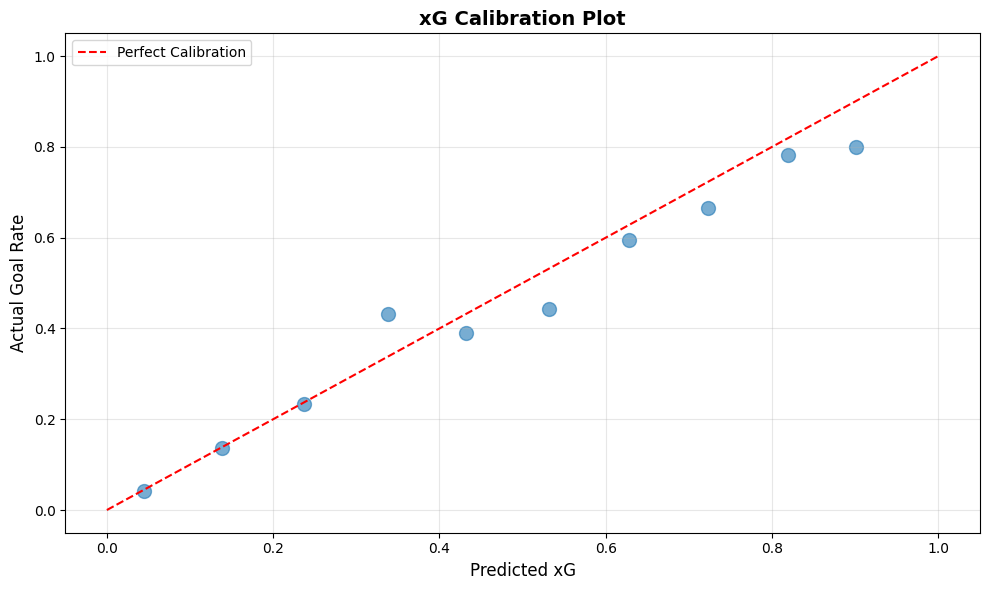

In [9]:
# 5. Plot calibration
xg_model.plot_xg_calibration(shots_df)

### 4. Plotting different stuff

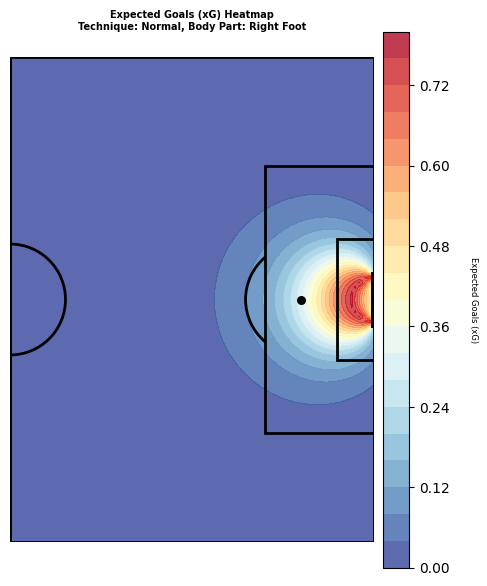

In [12]:
# # 1. Create basic xG heatmap
fig, ax = create_xg_heatmap(xg_model)
plt.show()

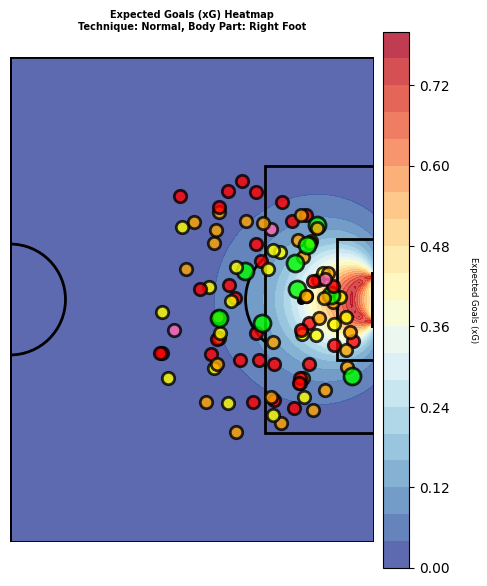

In [11]:
# 2. Create heatmap with actual shots overlaid
fig, ax = create_xg_heatmap_with_shots(xg_model, shots_df, max_shots=100)
plt.show()


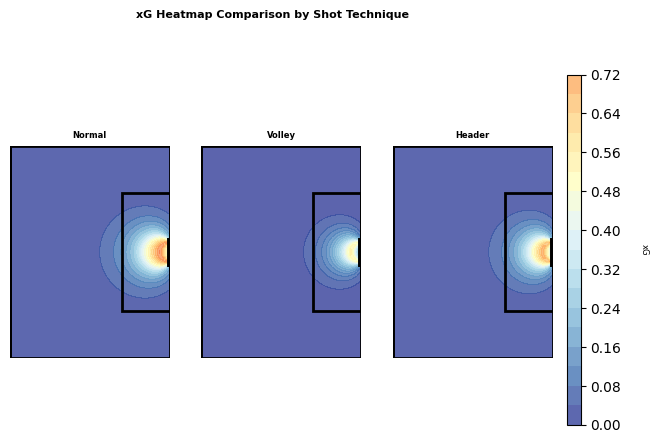

In [11]:
# 3. Compare different shot techniques
fig, axes = compare_xg_by_technique(xg_model, 
                                    techniques=['Normal', 'Volley', 'Header'])
plt.show()

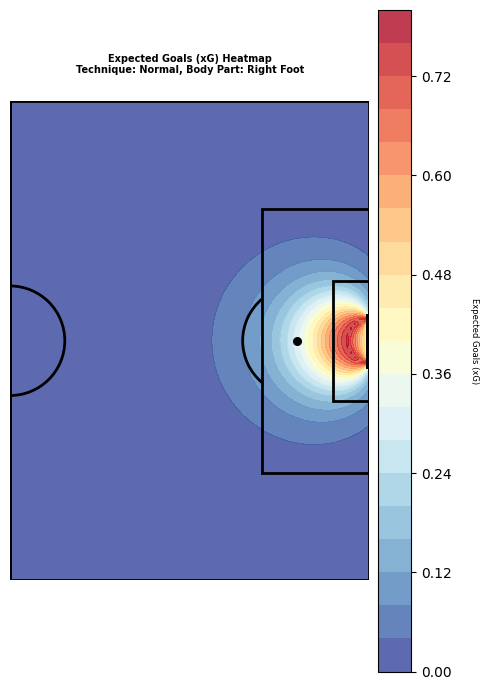

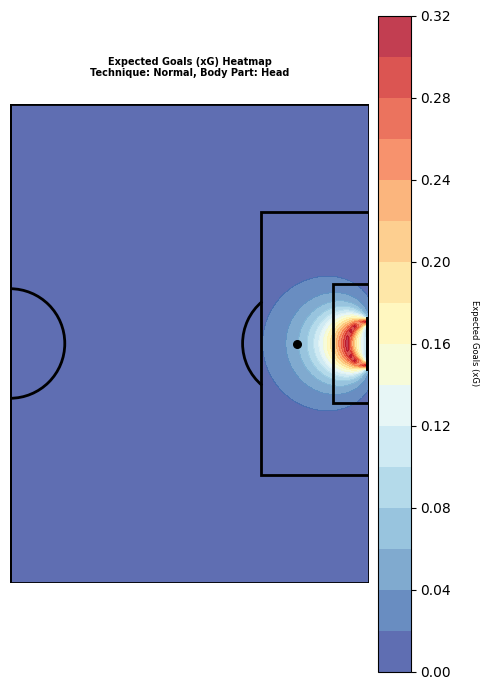

In [12]:
# 4. Compare body parts
fig, ax1 = create_xg_heatmap(xg_model, shot_body_part='Right Foot')
fig, ax2 = create_xg_heatmap(xg_model, shot_body_part='Head')
plt.show()